In [22]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [23]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
# Небольшой учебный датасет: короткие тексты и тематические метки.
samples = [
    # education
    ("На лекции подробно разобрали градиентный спуск и регуляризацию.", "education"),
    ("Студенты сдали домашнее задание по Python и анализу данных.", "education"),
    ("В университете открыли новую магистерскую программу по искусственному интеллекту.", "education"),
    ("Преподаватель объяснил, как работает кросс-валидация на практических примерах.", "education"),
    ("Курс по машинному обучению включает семинары, лабораторные и итоговый проект.", "education"),
    ("На занятии обсуждали переобучение модели и способы его уменьшить.", "education"),
    ("Школьники готовятся к олимпиаде по информатике и решают сложные задачи.", "education"),
    ("На семинаре мы сравнивали разные архитектуры нейронных сетей.", "education"),
    ("Экзамен по статистике пройдёт в письменной форме на следующей неделе.", "education"),
    ("Студент защитил проект по компьютерному зрению и получил высокий балл.", "education"),
    ("Для курса требуется базовое знание линейной алгебры и теории вероятностей.", "education"),
    ("В лаборатории обсуждали метрики качества классификации и матрицу ошибок.", "education"),
    ("Программа дополнительного образования рассчитана на специалистов из отрасли.", "education"),
    ("На консультации преподаватель помог исправить ошибки в ноутбуке с кодом.", "education"),
    ("Группа изучает токенизацию, attention и тонкую настройку трансформеров.", "education"),

    # technology
    ("Разработчики выкатили новую версию сервиса с улучшенным API и логированием.", "technology"),
    ("Модель обрабатывает текстовые запросы и возвращает структурированный ответ.", "technology"),
    ("Команда настроила CI/CD и автоматическую проверку качества кода.", "technology"),
    ("Инженеры оптимизировали инференс, чтобы сократить задержку ответа модели.", "technology"),
    ("В репозитории обновили зависимости и зафиксировали версии библиотек.", "technology"),
    ("Сервис развёрнут в контейнерах и использует очередь задач для фоновой обработки.", "technology"),
    ("Система мониторинга показывает рост загрузки GPU во время обучения модели.", "technology"),
    ("Разработчик добавил поддержку векторного поиска и работу с эмбеддингами.", "technology"),
    ("В приложении исправили ошибку сериализации JSON и проблему с кодировкой.", "technology"),
    ("Инженер описал архитектуру проекта, схему данных и правила деплоя.", "technology"),
    ("Стенд демонстрирует работу RAG-системы с поиском по внутренним документам.", "technology"),
    ("После обновления библиотек код стал работать быстрее и стабильнее.", "technology"),
    ("Модель классификации текста обучается в PyTorch и сохраняется в формате safetensors.", "technology"),
    ("Команда подключила трекинг экспериментов и хранение метрик обучения.", "technology"),
    ("Прототип использует токенизатор HuggingFace и BERT-подобную языковую модель.", "technology"),

    # sports
    ("Команда уверенно выиграла матч и поднялась на первое место в таблице.", "sports"),
    ("Тренер похвалил игроков за дисциплину и хорошую игру в обороне.", "sports"),
    ("Футболисты провели интенсивную тренировку перед важной встречей.", "sports"),
    ("На стадионе сегодня аншлаг: болельщики ждут принципиального дерби.", "sports"),
    ("Спортсмен улучшил личный рекорд и вышел в финал соревнований.", "sports"),
    ("Во втором тайме команда прибавила в скорости и переломила ход игры.", "sports"),
    ("Судья назначил пенальти в концовке матча, и трибуны взорвались эмоциями.", "sports"),
    ("Клуб объявил состав на сезон и представил нового главного тренера.", "sports"),
    ("После серии поражений команда наконец одержала долгожданную победу.", "sports"),
    ("Игрок пропустит следующий матч из-за травмы колена.", "sports"),
    ("Сборная успешно начала турнир и не пропустила ни одного мяча.", "sports"),
    ("Баскетболисты хорошо двигали мяч и уверенно реализовали дальние броски.", "sports"),
    ("Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах.", "sports"),
    ("На марафоне участники держали высокий темп почти всю дистанцию.", "sports"),
    ("В решающем сете теннисист сыграл хладнокровно и довёл матч до победы.", "sports"),
]

df = pd.DataFrame(samples, columns=["text", "label"])
# Примечание: для учебного задания здесь используется небольшой искусственный",
,
,
,
,
,

: 
,
: 
,
: {
: 

: [
,
Размер датасета:", len(df))
display(df["label"].value_counts())

label_names = sorted(df["label"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))

In [26]:
# Сначала отделяем test (20%), затем из оставшихся данных выделяем validation (25% от остатка),
# что в итоге даёт приблизительно 60/20/20.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["label_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (27, 3)
Validation: (9, 3)
Test: (9, 3)

Распределение классов в train:


label
sports        9
education     9
technology    9
Name: count, dtype: int64

Распределение классов в validation:


label
technology    3
sports        3
education     3
Name: count, dtype: int64

Распределение классов в test:


label
sports        3
education     3
technology    3
Name: count, dtype: int64

In [27]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 27
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 9
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 9
    })
})

In [28]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

Пример из train:


{'text': ['Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах.',
  'В университете открыли новую магистерскую программу по искусственному интеллекту.',
  'Группа изучает токенизацию, attention и тонкую настройку трансформеров.'],
 'labels': [1, 0, 0]}

Пример из validation:


{'text': ['Прототип использует токенизатор HuggingFace и BERT-подобную языковую модель.',
  'Модель обрабатывает текстовые запросы и возвращает структурированный ответ.',
  'На марафоне участники держали высокий темп почти всю дистанцию.'],
 'labels': [2, 2, 1]}

In [29]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


Map: 100%|██████████| 9/9 [00:00<00:00, 2371.30 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9
    })
})

In [30]:
# Смотрим, как теперь выглядит один пример после токенизации.
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("labels:", example["labels"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 1
input_ids[:20]: [2, 51252, 27351, 1241, 52357, 3910, 4495, 29827, 7592, 314, 6003, 35049, 52977, 18, 3]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах. [SEP]


In [31]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 16)
token_type_ids: shape=(3, 16)
attention_mask: shape=(3, 16)


In [32]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 7199.74it/s]
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

Model class: BertForSequenceClassification
Number of labels: 3
id2label: {0: 'education', 1: 'sports', 2: 'technology'}


In [33]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [34]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [35]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.095723,1.091601,0.555556,0.444444,0.444444
2,1.074461,1.082977,0.666667,0.535714,0.535714
3,1.082053,1.076519,0.666667,0.535714,0.535714
4,1.066682,1.072602,0.666667,0.535714,0.535714
5,1.093834,1.071138,0.666667,0.535714,0.535714


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.43it/s]
c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.52it/s]
c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.33it/s]
mtime may not be reliable on this filesystem, falling back to numerical ordering
c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loa

TrainOutput(global_step=20, training_loss=1.0780859470367432, metrics={'train_runtime': 5.3152, 'train_samples_per_second': 25.399, 'train_steps_per_second': 3.763, 'total_flos': 34225391376.0, 'train_loss': 1.0780859470367432, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.1006,1.5211,1.9000e-05,0.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0957,3.0592,1.7000e-05,1.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.0,4,1.0916,0.5556,0.4444,0.4444,0.0287,313.197,69.599,NaN,NaN,NaN,NaN,NaN
3,1.0904,1.7236,1.5000e-05,1.5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0745,2.7769,1.3000e-05,2.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,2.0,8,1.0830,0.6667,0.5357,0.5357,0.0358,251.271,55.838,NaN,NaN,NaN,NaN,NaN
6,1.0616,1.8069,1.1000e-05,2.5,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.0821,2.5058,9.0000e-06,3.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,3.0,12,1.0765,0.6667,0.5357,0.5357,0.0229,393.253,87.390,NaN,NaN,NaN,NaN,NaN
9,1.0672,1.5919,7.0000e-06,3.5,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


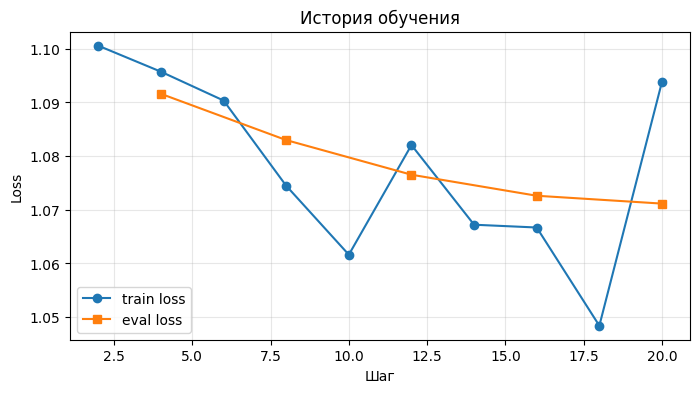

In [36]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [37]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 1.0829
eval_accuracy: 0.6667
eval_f1_macro: 0.5357
eval_f1_weighted: 0.5357
eval_runtime: 0.0296
eval_samples_per_second: 304.1040
eval_steps_per_second: 67.5790
epoch: 5.0000

Test metrics:
eval_loss: 1.0835
eval_accuracy: 0.6667
eval_f1_macro: 0.5556
eval_f1_weighted: 0.5556
eval_runtime: 0.0219
eval_samples_per_second: 410.6610
eval_steps_per_second: 91.2580
epoch: 5.0000


c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

   education       0.00      0.00      0.00         3
      sports       1.00      1.00      1.00         3
  technology       0.50      1.00      0.67         3

    accuracy                           0.67         9
   macro avg       0.50      0.67      0.56         9
weighted avg       0.50      0.67      0.56         9



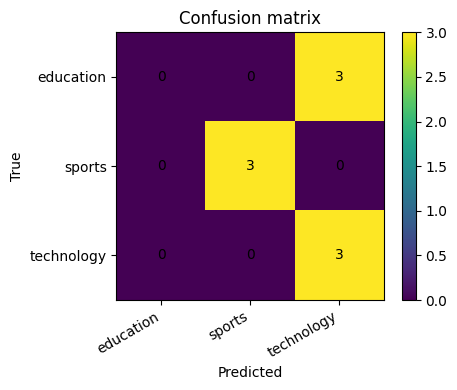

Saved confusion matrix to homeworks\HW13\artifacts\confusion_matrix.png


In [38]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
# Сохраняем изображение матрицы ошибок в артефакты (требование задания)
artifacts_dir = Path("homeworks/HW13/artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(artifacts_dir / "confusion_matrix.png", dpi=200)
print(f"Saved confusion matrix to {artifacts_dir / 'confusion_matrix.png'}")

In [39]:
# Вспомогательная функция для инференса новых текстов.
def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_vector in zip(texts, pred_ids, probs):
        row = {
            "text": text,
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)

new_texts = [
    "На курсе подробно объяснили, как считать precision, recall и F1.",
    "Команда ускорила обработку запросов и уменьшила время отклика сервиса.",
    "В концовке матча нападающий забил победный гол.",
    "Студенты обсуждали архитектуру трансформеров и механизм attention.",
    "После обновления API приложение стало стабильнее работать на сервере.",
    "Тренер сообщил, что игрок вернётся в состав только после восстановления.",
]

display(predict_texts(new_texts))

,text,pred_label,confidence,prob_education,prob_sports,prob_technology
0,"На курсе подробно объяснили, как считать precision, recall и F1.",technology,0.3488,0.3277,0.3235,0.3488
1,Команда ускорила обработку запросов и уменьшила время отклика сервиса.,technology,0.3572,0.3234,0.3194,0.3572
2,В концовке матча нападающий забил победный гол.,sports,0.3494,0.3363,0.3494,0.3143
3,Студенты обсуждали архитектуру трансформеров и механизм attention.,technology,0.3496,0.3173,0.3330,0.3496
4,После обновления API приложение стало стабильнее работать на сервере.,technology,0.3426,0.3344,0.3230,0.3426
5,"Тренер сообщил, что игрок вернётся в состав только после восстановления.",technology,0.3381,0.3268,0.3351,0.3381


In [40]:
# Таблица ошибок на тестовой выборке.
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))

# Сохраняем предсказания на тесте в artifacts/sample_predictions.csv (требование задания)
artifacts_dir = Path("homeworks/HW13/artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)
# Собираем полный датасет предсказаний с confidence для каждого примера
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
pred_rows = []
for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, probs):
    pred_rows.append({
        "text": text,
        "true_label": id2label[int(true_id)],
        "pred_label": id2label[int(pred_id)],
        "confidence": float(prob_vector[pred_id]),
    })
preds_df = pd.DataFrame(pred_rows)
preds_df.to_csv(artifacts_dir / "sample_predictions.csv", index=False)
print(f"Saved sample predictions to {artifacts_dir / 'sample_predictions.csv'}")
display(preds_df.head(10))

,text,true_label,pred_label,pred_confidence
0,Школьники готовятся к олимпиаде по информатике и решают сложные задачи.,education,technology,0.3582
1,Программа дополнительного образования рассчитана на специалистов из отрасли.,education,technology,0.3515
2,"Преподаватель объяснил, как работает кросс-валидация на практических примерах.",education,technology,0.3422


Saved sample predictions to homeworks\HW13\artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,В решающем сете теннисист сыграл хладнокровно и довёл матч до победы.,sports,sports,0.3553
1,Школьники готовятся к олимпиаде по информатике и решают сложные задачи.,education,technology,0.3582
2,"Инженер описал архитектуру проекта, схему данных и правила деплоя.",technology,technology,0.3450
3,Программа дополнительного образования рассчитана на специалистов из отрасли.,education,technology,0.3515
4,Сервис развёрнут в контейнерах и использует очередь задач для фоновой обработки.,technology,technology,0.3422
5,Футболисты провели интенсивную тренировку перед важной встречей.,sports,sports,0.3526
6,Клуб объявил состав на сезон и представил нового главного тренера.,sports,sports,0.3419
7,После обновления библиотек код стал работать быстрее и стабильнее.,technology,technology,0.3444
8,"Преподаватель объяснил, как работает кросс-валидация на практических примерах.",education,technology,0.3422
